# Homework 1 - Linear Regression

## Dataset
The dataset you will be using is about Life expectancy of different countries. We will explore how immunization factors, mortality factors, economic factors, social factors and other health related factors affect Life expectancy of a country.

There are two data files: "LifeExpectancy_training.csv" and "LifeExpectancy_test.csv"<br/>
Both files have the following fields, except Life_expectancy which is not available in "LifeExpectancy_test.csv"

Features :
- Year : from 2000 to 2015
- Status : Developed or Developing status
- Adult_Mortality : Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)
- Alcohol : Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)
- percentage_expenditure : Expenditure on health as a percentage of Gross Domestic Product per capita(%)
- BMI: Average Body Mass Index of entire population
- Total_expenditure: General government expenditure on health as a percentage of total government expenditure (%)
- Diphtheria: Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)
- HIV_AIDS: Deaths per 1000 live births HIV/AIDS (0-4 years)
- GDP: Gross Domestic Product per capita (in USD)
- Population
- Income_composition_of_resources: Human Development Index in terms of income composition of resources (index ranging from 0 to 1)
- Schooling: Number of years of Schooling(years)

Target:
- Life_expectancy: Life Expectancy in age


Training dataset, "LifeExpectancy_training.csv", contains 1154 rows and 14 columns. This is the training set containing both of the features and the target.<br/>
Test dataset, "LifeExpectancy_test.csv", contains 495 rows and 13 columns. This is the test set which only contains the features.<br/>

Your goal is to predict Life expectancy based on the features.

In [1]:
import numpy as np
import pandas as pd

Load the training data "LifeExpectancy_training.csv" in Colab and View the first 5 lines

In [2]:
from google.colab import files
uploaded = files.upload()

Saving LifeExpectancy_training.csv to LifeExpectancy_training.csv


In [3]:
# Load the training data
import io
df = pd.read_csv(io.BytesIO(uploaded['LifeExpectancy_training.csv']))

In [4]:
# Show the first 5 lines to see what the data looks like
### WRITE CODE ###
df.head()

,Year,Status,Adult_Mortality,Alcohol,percentage_expenditure,BMI,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,Income_composition_of_resources,Schooling,Life_expectancy
0,2011,Developing,93,1.57,835.062683,64.0,7.12,81,0.1,8734.96530,4588368.0,0.758,13.2,75.0
1,2014,Developing,152,6.41,789.077295,32.4,4.12,99,0.1,5941.84710,68416772.0,0.737,13.6,74.6
2,2013,Developed,68,11.82,90.585012,56.6,11.14,95,0.1,554.71532,8479375.0,0.887,15.7,81.1
3,2014,Developed,135,0.01,1.576409,59.9,5.57,94,0.1,12.27733,1998979.0,0.797,14.7,74.8
4,2002,Developing,192,5.93,27.638103,2.2,3.70,96,0.7,296.54617,6473164.0,0.657,11.5,71.4


## Data Exploration
We can plot a histogram of the dataframe for the features except "Status" to understand their distributions. <br/>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import sklearn.model_selection
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statistics import mean
from sklearn import datasets
import seaborn as sns
import io


Distributions:


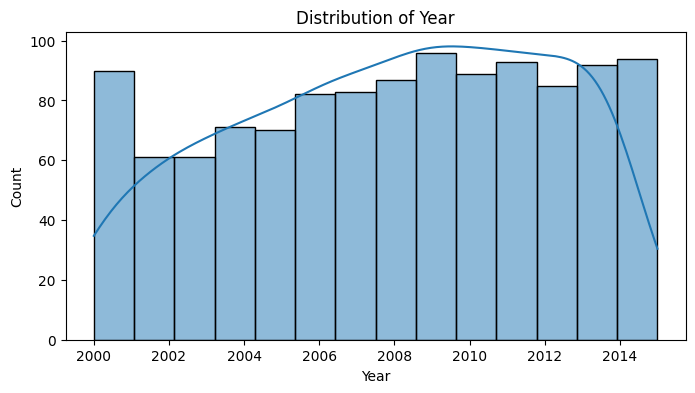

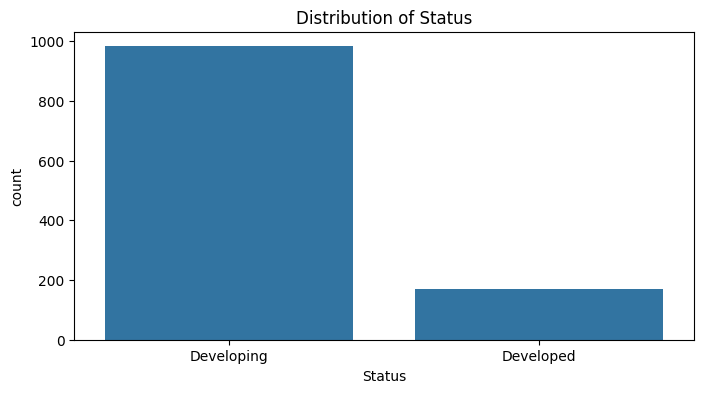

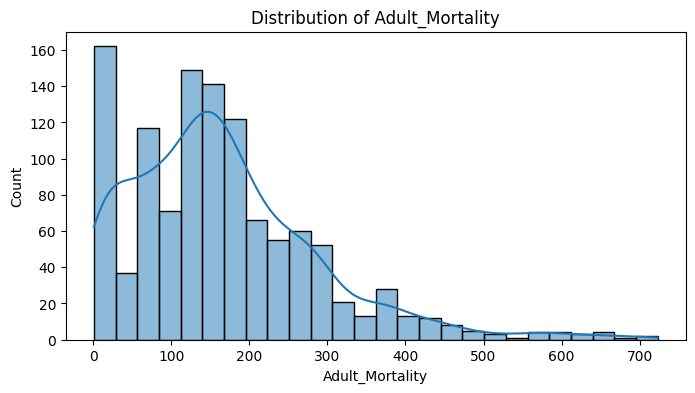

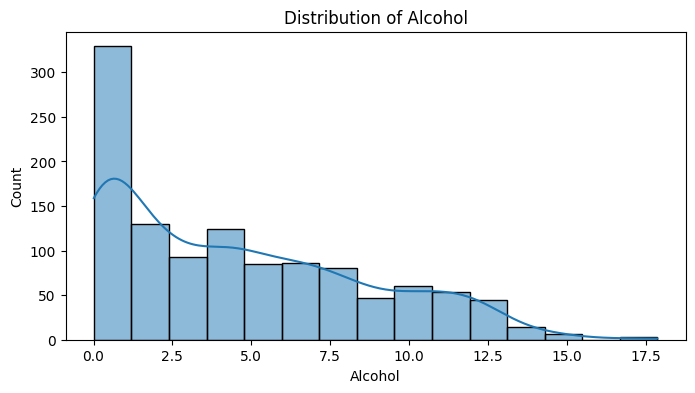

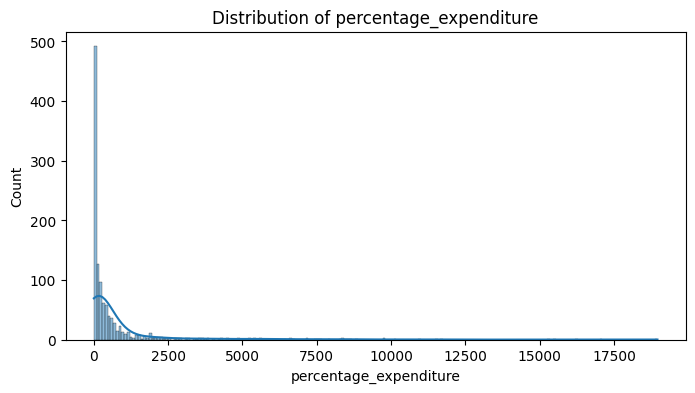

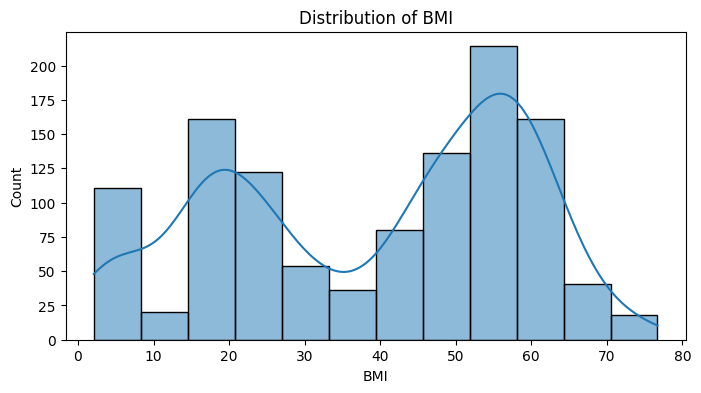

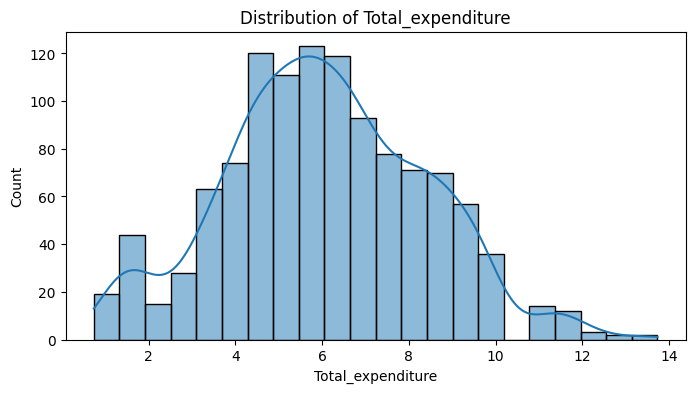

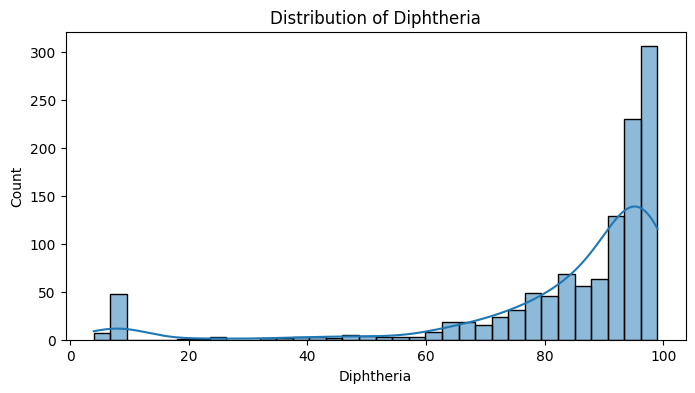

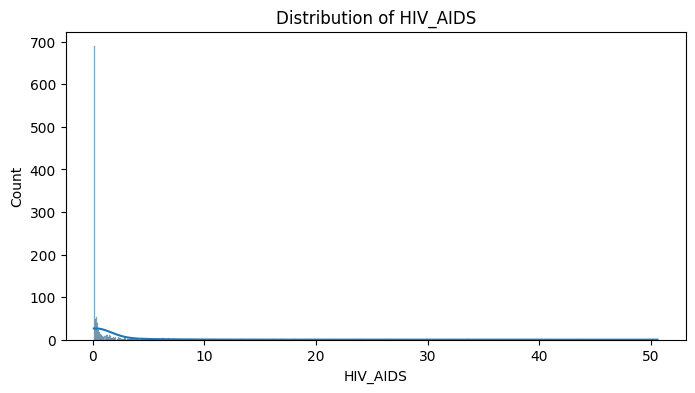

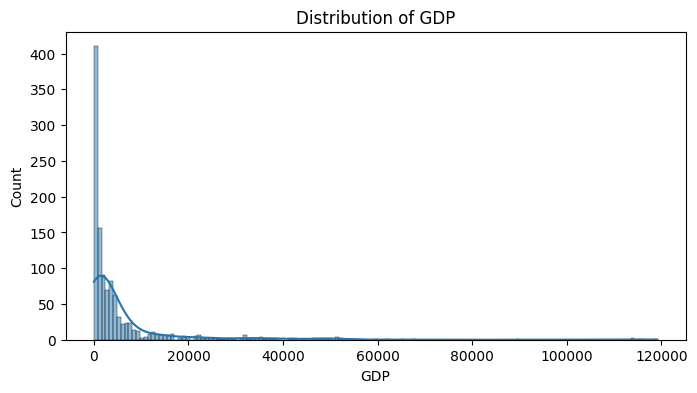

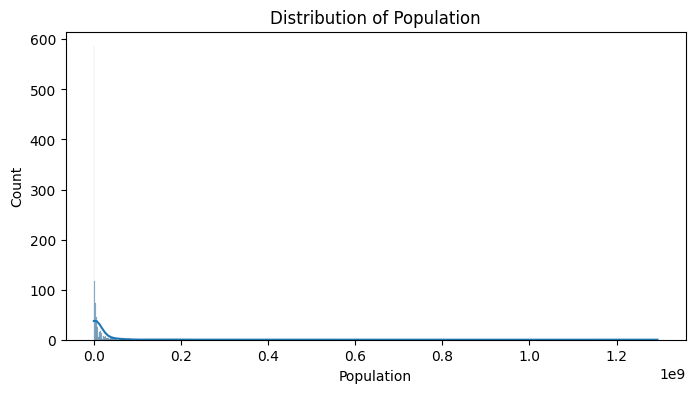

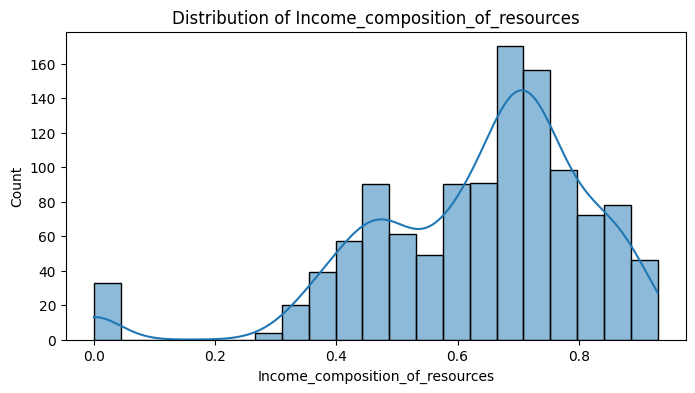

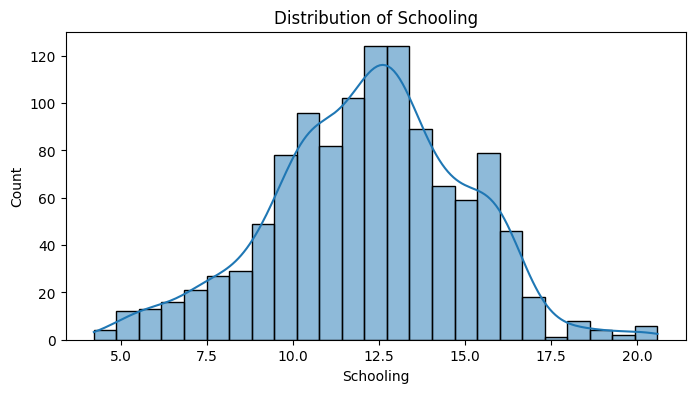

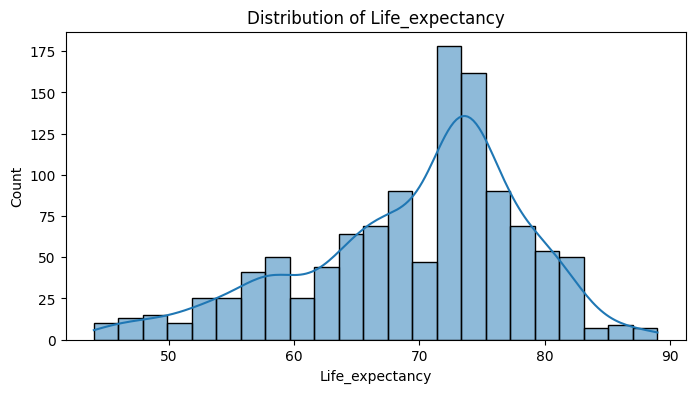

In [6]:
### WRITE CODE TO OBTAIN AND DISPLAY HISTOGRAMS ###
print("\nDistributions:")
for column in df.columns:
    plt.figure(figsize=(8, 4))
    if df[column].dtype == 'object':
        sns.countplot(x=df[column])
    else:
        sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

##### Q1. What can you infer from the histograms? <br/>
Ans-
Looking at the histograms, we can notice the various distributions of our explanatory variables.  
- *Year* appears to be uniformly distributed, with values evenly spread across the range of 2000-2015.
-*Status* is a binary variable, resulting in two bars ('developing' & developed) in the histogram.
-*Adult_Mortality*, *Alcohol*, *percentage_expenditure*, *HIV_AIDS*, *GDP*, and *Population* are all right skewed, with most of the values clustered at the lower end.  
-*Diptheria* and *Life_expectancy* are both left skewed, with most values on the higher end.
-*Total_expenditure* and *Schooling* are both unimodal, showing a single peak.
-*BMI* and *Income_composition_of_resources* are both bimodal.

Compute the correlation matrix to get an understanding of the correlation between life_expectancy and the other features.<br/>

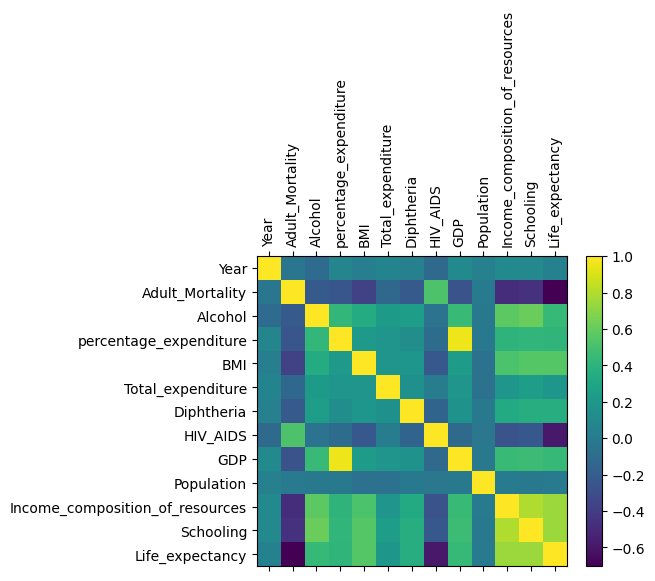

In [7]:
### WRITE CODE TO OBTAIN CORRELATION MATRIX ###
correlation_matrix = df.select_dtypes(include=[float, int]).corr()

# Plot the correlation matrix with labels
plt.figure(figsize=(5, 4))
plt.matshow(correlation_matrix, fignum=1)
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.show()

##### Answer the following questions:<br/>

##### Q2. Why is the diagonal made up of 1's in the correlation matrix?<br/>
Ans- Because the diagonal line is showing the correlation between each variable and themselves, and it's always perfect, so that the diagonal is all made up of one.
$$\operatorname{Corr}(X, X) = \frac{\operatorname{Cov}(X, X)}{\sigma_X \sigma_X} = \frac{\sigma_X^2}{\sigma_X^2} = 1$$

---
##### Q3. Why is the matrix symmetric along diagonal?<br/>
Ans- Because the correlation between two variables is the same in any order, so that the matrix is symmetric along the diagonol like composited with the 1's.
$$\operatorname{Corr}(X, Y) = \operatorname{Cov}(Y, X)$$

---
##### Q4. Looking at the correlation matrix, if you have to choose one predictor for a simple linear regression model with Life_expectancy as the outcome, which one would you choose and why? <br/>
Ans- If we are choosing one predictor for a simple linear regression, it should be the prediction with relatively high correlation (either positive or negative) with the outcome (Life_expectancy) as well as, being meaningful in terms of its possible predictive ability to be used as the predictor. Following this two points, we consider Schooling as the most ideal predictor in this case.

We can notice that Schooling and Income_composition_of_resources have the highest correlation with Life_expectancy. However, since Schooling is a numerical feature and not binary like Income_composition_of_resources, Schooling would be a better predictor for Life_expectancy, which is also numerical.


### Standardization of features

Feature standardization makes the values of each feature in the data have zero-mean and unit-variance. This method is widely used for normalization in many machine learning algorithms. The general method of calculation is to determine the distribution mean and standard deviation for each feature. Next we subtract the mean from each feature. Then we divide the values of each feature by its standard deviation.

$x'$ = ($x$ - $\bar{x}$)/$\sigma$

where $x$ is the original feature vector,
$\bar{x}$ is the mean of the feature vector and
$\sigma$ is its standard deviation.

This is also called Z-score Normalization.

Perform Z-score Normalization on the features (except "Year" and "Status") in both training and test set.

In [8]:
# Load the test set "LifeExpectancy_test.csv"
### WRITE CODE ###
uploaded_test = files.upload()

Saving LifeExpectancy_test.csv to LifeExpectancy_test.csv


In [9]:
df_test = pd.read_csv(io.BytesIO(uploaded_test['LifeExpectancy_test.csv']))

In [10]:
from sklearn.preprocessing import StandardScaler
### WRITE CODE TO PERFORM Z-score Normalization ###
normalize_df = df.copy()
normalize_dftest = df_test.copy()

columns_change = [col for col in normalize_df.columns if col not in ['Year', 'Status', 'Life_expectancy']]
scaler = StandardScaler()
normalize_df[columns_change] = scaler.fit_transform(normalize_df[columns_change])

print("DataFrame after Z-score normalization for training set:")
print(normalize_df)

DataFrame after Z-score normalization for training set:
      Year      Status  Adult_Mortality   Alcohol  percentage_expenditure  \
0     2011  Developing        -0.596230 -0.746122                0.058789   
1     2014  Developing        -0.111399  0.462190                0.033498   
2     2013   Developed        -0.801666  1.812804               -0.350645   
3     2014   Developed        -0.251096 -1.135578               -0.399597   
4     2002  Developing         0.217300  0.342358               -0.385264   
...    ...         ...              ...       ...                     ...   
1149  2013  Developing        -0.062094 -1.135578               -0.398605   
1150  2006   Developed        -0.818101  1.435830                3.002182   
1151  2009  Developing        -1.261845 -0.788563               -0.078389   
1152  2012  Developing         0.619956 -0.678716               -0.352713   
1153  2010  Developing         0.184430 -0.863458               -0.384228   

           BMI  Tot

In [11]:
columns_change_test = [col for col in normalize_dftest.columns if col not in ['Year', 'Status', 'Life_expectancy']]
normalize_dftest[columns_change_test] = scaler.fit_transform(normalize_dftest[columns_change_test])

print("DataFrame after Z-score normalization for test set:")
print(normalize_dftest)

DataFrame after Z-score normalization for test set:
     Year      Status  Adult_Mortality   Alcohol  percentage_expenditure  \
0    2011  Developing         0.756055 -1.094334               -0.387676   
1    2008  Developing         0.846254 -1.089430               -0.376007   
2    2011  Developing        -0.649533  0.219699               -0.120471   
3    2005  Developing        -1.198239  0.168216               -0.375312   
4    2003  Developing        -1.175690 -0.045069               -0.382939   
..    ...         ...              ...       ...                     ...   
490  2006  Developing         2.642701 -0.545186               -0.390931   
491  2010  Developing         2.650218  0.180474               -0.358958   
492  2008  Developing         3.439452 -0.224032               -0.379133   
493  2005  Developing         4.078356 -0.081842               -0.386669   
494  2001  Developing         3.845344 -0.675118               -0.392087   

          BMI  Total_expenditure  D

##### Q5. What are the advantages and disadvantages of using Z-score Normalization?<br/>
Ans-  

Advantages of Z-score Normalization：First, it centers data with mean of 0 and standard deviation of 1. It standardizes data by centering it around zero, making it easier for many machine learning algorithms to converge faster and perform more accurately. Secondly, the Z-score normalization could help preserve the shape of the original data distribution. It is especially helpful when considering some outliers that relate to important information. Thirdly, when combining datasets with largely different scales or units, Z-score normalization brings them to a common scale, which makes them easier to compare and analyze together.

Disadvantages of Z-score Normalization：It might not work well if the data is not normally distributed or highly skewed. If the dataset is not large enough, a few extreme values can heavily influence the mean and standard deviation, which can make the test statistic z-scores unreliable. After Z-score normalization, some values can become negative. This could be a problem if the algorithm you’re using doesn’t handle negative values well. It is also not suitable for the binary data since it treats those values as they are continuous. Additionally, it doesn't work well if we get new data since we might need to recalculate the mean and standard deviation and then reapply the normalization.

##### Q6. In this dataset, do you need to use the Z-score Normalization? Explain.<br/>
Ans- If the features are on scaled differently, then we need to use Z-score Normalization. As shown in the dataset, the range of every column is almost different from each other. Specifically, the range of the column called Population is much larger than those of other columns. Z-score Normalization could help bring all of the columns to a common scale, where the data is centered around 0 and standard deviation of 1. This would help the machine learning algorithms we use perform more efficiently. Normalization helps provide more accurate VIF outputs and hence benefits the model accuracy as a whole. Thus, we need to use the Z-score Normalization.

### One-Hot Encoding

"Year" and "Status" can only take discrete values. We need to perform one-hot encoding on discrete values for it to be processed in the model. One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.
Perform one-hot encoding on "Year" and "Status" and print the shape of your encoded array

In [12]:
from sklearn.preprocessing import OneHotEncoder
### WRITE CODE TO PERFORM ONE-HOT CODING ON "Year" AND "Status" ###

# Select the 'Year' and 'Status' columns
columns_to_encode = ['Year', 'Status']
categorical_data = df[columns_to_encode]

# Apply OneHotEncoder to these two columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_encoded = encoder.fit_transform(categorical_data)

print("Shape of the encoded array:", categorical_encoded.shape)

encoded_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(columns_to_encode))

normalize_df = normalize_df.drop(columns=columns_to_encode)
normalize_df = pd.concat([normalize_df, encoded_df], axis=1)

Shape of the encoded array: (1154, 16)


In [13]:
# Check if the one-hot encoding on "Year" and "Status" is correct
normalize_df.head()

,Adult_Mortality,Alcohol,percentage_expenditure,BMI,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,Income_composition_of_resources,...,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Year_2013,Year_2014,Year_2015,Status_Developing
0,-0.596230,-0.746122,0.058789,1.260316,0.455246,-0.172026,-0.304462,0.244064,-0.140504,0.668903,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.111399,0.462190,0.033498,-0.333480,-0.836894,0.686328,-0.304462,0.011425,0.961461,0.553909,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.801666,1.812804,-0.350645,0.887085,2.186713,0.495582,-0.304462,-0.437269,-0.073327,1.375298,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.251096,-1.135578,-0.399597,1.053526,-0.212360,0.447896,-0.304462,-0.482448,-0.185208,0.882465,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.217300,0.342358,-0.385264,-1.856665,-1.017793,0.543269,-0.198197,-0.458771,-0.107964,0.115834,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
# One-Hot Encoding for Test Dataset
Year_2015_test = normalize_dftest['Year'].apply(lambda x: 1.0 if x == 2015 else 0.0) # For Multiple Linear Regression Use

categorical_data_test = df_test[columns_to_encode]

encoder_test = OneHotEncoder(sparse_output=False, drop='first')
categorical_encoded_test = encoder_test.fit_transform(categorical_data_test)

encoded_dftest = pd.DataFrame(categorical_encoded_test, columns=encoder_test.get_feature_names_out(columns_to_encode))

normalize_dftest = normalize_dftest.drop(columns=columns_to_encode)
normalize_dftest = pd.concat([normalize_dftest, encoded_dftest], axis=1)

In [15]:
# Check if the one-hot encoding on "Year" and "Status" is correct for Test Dataset
normalize_dftest.head()

,Adult_Mortality,Alcohol,percentage_expenditure,BMI,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,Income_composition_of_resources,...,Year_2006,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Year_2013,Year_2014,Status_Developing
0,0.756055,-1.094334,-0.387676,-0.972240,0.972884,-0.659990,-0.332187,-0.489852,-0.173547,-0.912468,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.846254,-1.089430,-0.376007,-1.049526,1.179708,-0.834810,-0.332187,-0.459168,-0.176222,-1.026841,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.649533,0.219699,-0.120471,0.980536,0.001708,0.694866,-0.332187,-0.056699,-0.202352,0.634297,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.198239,0.168216,-0.375312,0.712609,0.186051,0.651161,-0.332187,-0.468499,-0.202177,0.345640,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.175690,-0.045069,-0.382939,0.609560,0.253494,0.607455,-0.332187,-0.477359,-0.201876,0.285730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Q7. What are the advantages and disadvantages of using One-hot encoding?

Ans- One-Hot Encoding offers several advantages, particularly dealing with categorical variables. Its primary advantage is that it avoids imposing any ordinal relationships on variables like ‘Year’ and ‘Status’, which don't have a natural ranking. One-Hot Encoding ensures that no one value is mistakenly treated as “greater” or ‘lesser” than another. This method is also very intuitive to interpret, as each category is represented by a separate column, making interpretation straightforward and improving the compatibility with many machine learning models that require numerical inputs.
However, One-Hot Encoding also has some disadvantages, especially when categorical value have many unique values. For example, in the given dataset, the shape expands to (1154, 18) after encoding, showing that the dimensionality increases significantly due to the high number of unique values in ‘Year’ and ‘Status’. This expansion can lead to:

1.        Increased training time: As the number of features/ column increases, model training will become slower. It can be problematic when dealing with a large datasets or when using algorithms sensitive to number of features.

2.        Higher Risk of Overfitting: with more features, especially sparse feature created by One-Hot encoding, some models may have the risk of overfitting training data, in particular when the dataset is small but has high dimensional one-hot encoded variables.


## Multiple Linear Regression

In the big data era, it is highly unlikely that we are interested in the effect of a single variable on another. To simultaneously account for the effects of multiple variables, we use multiple regression (which accounts for the covariances between predictors).

While the algorithmic solution to multiple regression exists, it is easier to conceptualize in terms of linear algebra. The optimal $\hat{\beta}$ vector that minimizes the residual sum of squares is:

$\hat{\beta} = (X^TX)^{-1}X^Ty $


Perform multiple linear regression on the training dataset, where the outcome is "Life_expectancy".

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
### Bulding and fitting the Multiple Linear Regression model###

# Separate the features and the target variable
X = normalize_df.drop('Life_expectancy', axis=1)
y = normalize_df['Life_expectancy']

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
### Evaluate the Linear Regression model by computing MSE on the training set###
from sklearn.metrics import mean_squared_error

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f'The MSE of the training set is: {mse_train}')

The MSE of the training set is: 12.772613206174421


In [19]:
# For Test dataset
normalize_dftest.insert(len(normalize_dftest.columns) - 1, 'Year_2015', Year_2015_test)
normalize_dftest.head()

,Adult_Mortality,Alcohol,percentage_expenditure,BMI,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,Income_composition_of_resources,...,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Year_2013,Year_2014,Year_2015,Status_Developing
0,0.756055,-1.094334,-0.387676,-0.972240,0.972884,-0.659990,-0.332187,-0.489852,-0.173547,-0.912468,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.846254,-1.089430,-0.376007,-1.049526,1.179708,-0.834810,-0.332187,-0.459168,-0.176222,-1.026841,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.649533,0.219699,-0.120471,0.980536,0.001708,0.694866,-0.332187,-0.056699,-0.202352,0.634297,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.198239,0.168216,-0.375312,0.712609,0.186051,0.651161,-0.332187,-0.468499,-0.202177,0.345640,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.175690,-0.045069,-0.382939,0.609560,0.253494,0.607455,-0.332187,-0.477359,-0.201876,0.285730,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
uploaded_ytest = files.upload()

Saving LifeExpectancy_ytest.csv to LifeExpectancy_ytest.csv


In [21]:
y_actual = pd.read_csv(io.BytesIO(uploaded_ytest["LifeExpectancy_ytest.csv"]))

In [22]:
y_traintest = model.predict(normalize_dftest)
mse_test = mean_squared_error(y_actual, y_traintest)
print(f'The MSE of the test set is: {mse_test}')

The MSE of the test set is: 15.410356710548127


Q8. Print the value of coefficients and also the corresponding variable names for the coefficients.

In [23]:
model_coefficients = pd.DataFrame({
    'Predictor': X_train.columns,
    'Coefficient': model.coef_
})

# Display intercept
print("Intercept:", model.intercept_)

# Display the value of coefficients and the corresponding variable names
print("\nPredictors and their Coefficients:")
print(model_coefficients)

Intercept: 71.52773683048005

Predictors and their Coefficients:
                          Predictor  Coefficient
0                   Adult_Mortality    -2.290085
1                           Alcohol    -0.190826
2            percentage_expenditure     0.581369
3                               BMI     0.672605
4                 Total_expenditure     0.177282
5                        Diphtheria     0.466465
6                          HIV_AIDS    -2.508333
7                               GDP     0.105663
8                        Population    -0.088533
9   Income_composition_of_resources     1.895519
10                        Schooling     2.532384
11                        Year_2001    -0.645935
12                        Year_2002    -1.477573
13                        Year_2003    -0.875477
14                        Year_2004    -1.157804
15                        Year_2005    -1.159830
16                        Year_2006    -1.292127
17                        Year_2007    -1.211019
18  

Q9. Is there a problem of multicollinearity? Explain what you can do

Ans-  We can assume that there will be some form of multicollinearity because we performed One-Hot-Encoding on 'Year'. Additionally, from the correlation matrix, there's strong evidence of multicollinearity due to the high correlation between other independent variables, such as GDP and percentage_expenditure. We can further confirm the issue of multicollinearity by calculating VIF values for each feature. A VIF value above 10 indicates multicollinearity and we should sequentially drop the top feature on the VIF list until each of the features have a VIF value below our threshold of 10. In this case, we only need to drop GDP.

In [24]:
# Calculate VIF to see if there is problem of multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_with_const = add_constant(X)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X.columns))]

print(vif.sort_values(by='VIF', ascending=False))

                            Feature        VIF
7                               GDP  13.363858
2            percentage_expenditure  12.463152
10                        Schooling   3.544629
9   Income_composition_of_resources   3.206152
24                        Year_2014   2.920573
19                        Year_2009   2.888486
23                        Year_2013   2.862581
21                        Year_2011   2.862020
20                        Year_2010   2.767749
22                        Year_2012   2.758063
18                        Year_2008   2.744967
17                        Year_2007   2.651420
16                        Year_2006   2.639440
14                        Year_2004   2.442391
15                        Year_2005   2.424989
1                           Alcohol   2.303271
12                        Year_2002   2.239605
13                        Year_2003   2.239289
11                        Year_2001   1.928090
26                Status_Developing   1.798948
0            

In [25]:
# Drop the feature with the highest VIF
X_dropped = X.drop('GDP', axis=1)
X_with_const = add_constant(X_dropped)
vif = pd.DataFrame()
vif['Feature'] = X_dropped.columns
vif['VIF'] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X_dropped.columns))]
print(vif.sort_values(by='VIF', ascending=False))

                            Feature       VIF
9                         Schooling  3.526491
8   Income_composition_of_resources  3.190003
23                        Year_2014  2.899655
18                        Year_2009  2.887744
20                        Year_2011  2.855170
22                        Year_2013  2.853189
19                        Year_2010  2.766544
21                        Year_2012  2.742012
17                        Year_2008  2.738657
16                        Year_2007  2.648965
15                        Year_2006  2.639360
13                        Year_2004  2.440115
14                        Year_2005  2.423358
1                           Alcohol  2.302415
11                        Year_2002  2.239142
12                        Year_2003  2.238734
10                        Year_2001  1.927523
25                Status_Developing  1.782742
0                   Adult_Mortality  1.781023
3                               BMI  1.537290
6                          HIV_AID

### Consolidating `Year` to 4 categories

In the consideration of computational efficiency, the encoded 'Year' has caught our attention and we further looked into the distribution of `Life_expectancy` by `Year` as well as the correlation between `Life_expectancy` and `Year`. It can be inferred that `Life_expectancy` does not varied a lot along different year and the correlation is indeed pretty low. Therefore we re-encoded `Year`(2000-2015, altogether 16 years) to four categories and again, applied the logic of one-encoding with dropping one category to avoid multicollinearity issue.

<Figure size 1200x600 with 0 Axes>

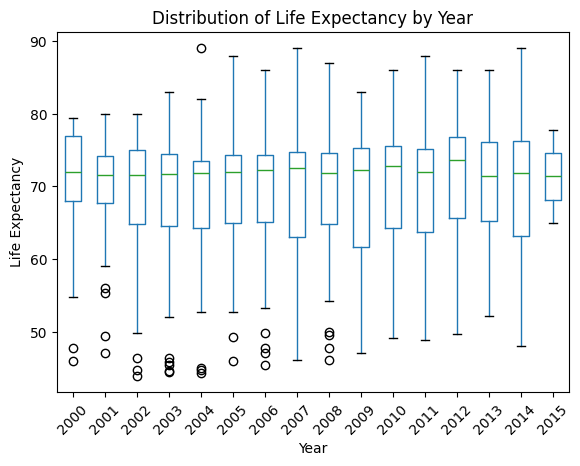

In [26]:
graph_data = pd.read_csv(io.BytesIO(uploaded['LifeExpectancy_training.csv']))

plt.figure(figsize=(12, 6))
graph_data.boxplot(column='Life_expectancy', by='Year', grid=False)
plt.title("Distribution of Life Expectancy by Year")
plt.suptitle('')
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Define the new groups based on previous one-hot encoded year columns
X_dropped['year_group1'] = X_dropped[['Year_2004', 'Year_2005', 'Year_2006', 'Year_2007']].sum(axis=1)
X_dropped['year_group2'] = X_dropped[['Year_2008', 'Year_2009', 'Year_2010', 'Year_2011']].sum(axis=1)
X_dropped['year_group3'] = X_dropped[['Year_2012', 'Year_2013', 'Year_2014', 'Year_2015']].sum(axis=1)


X_dropped['year_group1'] = X_dropped['year_group1'].apply(lambda x: 1 if x > 0 else 0)
X_dropped['year_group2'] = X_dropped['year_group2'].apply(lambda x: 1 if x > 0 else 0)
X_dropped['year_group3'] = X_dropped['year_group3'].apply(lambda x: 1 if x > 0 else 0)


X_dropped.drop(columns=[col for col in X_dropped.columns if 'Year_' in col], inplace=True)

# Display the first few rows to check
print(X_dropped.head())

   Adult_Mortality   Alcohol  percentage_expenditure       BMI  \
0        -0.596230 -0.746122                0.058789  1.260316   
1        -0.111399  0.462190                0.033498 -0.333480   
2        -0.801666  1.812804               -0.350645  0.887085   
3        -0.251096 -1.135578               -0.399597  1.053526   
4         0.217300  0.342358               -0.385264 -1.856665   

   Total_expenditure  Diphtheria  HIV_AIDS  Population  \
0           0.455246   -0.172026 -0.304462   -0.140504   
1          -0.836894    0.686328 -0.304462    0.961461   
2           2.186713    0.495582 -0.304462   -0.073327   
3          -0.212360    0.447896 -0.304462   -0.185208   
4          -1.017793    0.543269 -0.198197   -0.107964   

   Income_composition_of_resources  Schooling  Status_Developing  year_group1  \
0                         0.668903   0.361049                1.0            0   
1                         0.553909   0.505181                1.0            0   
2          

In [28]:
# Redo VIF to see if there is multicollinearity
X_with_const = add_constant(X_dropped)
vif = pd.DataFrame()
vif['Feature'] = X_dropped.columns
vif['VIF'] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X_dropped.columns))]
print(vif.sort_values(by='VIF', ascending=False))

                            Feature       VIF
9                         Schooling  3.486730
8   Income_composition_of_resources  3.153590
1                           Alcohol  2.282992
12                      year_group2  1.916842
13                      year_group3  1.905039
11                      year_group1  1.818205
10                Status_Developing  1.775743
0                   Adult_Mortality  1.767587
3                               BMI  1.529641
6                          HIV_AIDS  1.437532
2            percentage_expenditure  1.389269
5                        Diphtheria  1.175881
4                 Total_expenditure  1.119797
7                        Population  1.015104


### Goodness of fit

A model can always make predictions. But it is important to determine how good the model is.
How do we know that our model captures the data well? When evaluating model fit, a good metric is $R^2$, which corresponds to the amount of variance explained by the model. The formula for $R^2$ is the following:

$R^2$ = $1 - \dfrac{RSS}{TSS}$<br/>
where:<br/>
$RSS = \Sigma(y - \hat{y})^2$<br/>
$TSS = \Sigma(y - \bar{y})^2$<br/>

$R^2$ is also one metric for comparing models against each other. It is intuitive to say that the model that explains more variation in the data is a better fit than one that explains less variation.

Fill in the code for calculation of R2 score

In [29]:
from sklearn.metrics import r2_score

$R^2$ for model with "Schooling" as predictor and "Life_expectancy" as outcome

In [30]:
### WRITE CODE ###
X_1 = normalize_df[['Schooling']]
y_1 = normalize_df['Life_expectancy']

X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.25, random_state=42)


model_1 = LinearRegression()
model_1.fit(X_1_train, y_1_train)

# Predict
y_1_train_pred = model_1.predict(X_1_train)

# Print R2 score
r2_train_1 = r2_score(y_1_train, y_1_train_pred)
print(r2_train_1)

0.5560577785489771


$R^2$ for model with "Schooling", "Adult_Mortality" as predictor and "Life_expectancy" as outcome

In [31]:
X_2 = normalize_df[['Schooling', 'Adult_Mortality']]
y_2 = normalize_df['Life_expectancy']

X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, test_size=0.25, random_state=42)

model_2 = LinearRegression()
model_2.fit(X_2_train, y_2_train)

# Predict
y_2_train_pred = model_2.predict(X_2_train)

# Print R2 score
r2_train_2 = r2_score(y_2_train, y_2_train_pred)
print(r2_train_2)

0.7309674689476378


$R^2$ for model with "Schooling","Adult_Mortality" and "Population" as predictor and "Life_expectancy" as outcome

In [32]:
X_3 = normalize_df[['Schooling', 'Adult_Mortality', 'Population']]
y_3 = normalize_df['Life_expectancy']

X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, test_size=0.25, random_state=42)

model_3 = LinearRegression()
model_3.fit(X_3_train, y_3_train)

# Predict
y_3_train_pred = model_3.predict(X_3_train)

# Print R2 score
r2_train_3 = r2_score(y_3_train, y_3_train_pred)
r2_train_3

0.7311325295668364

You can see $R^2$ is always going up as we keep adding features.

This is one drawback of only using $R^2$ to evaluate your model. Adding predictors seems to always improve the predictive ability of your model, though it may not be true.

That is to say, we are not necessarily interested in making a perfect prediciton of our training data. If we were, we would always use all of the predictors available. Rather, we would like to make a perfect prediction of our test data. In this case, adding all the predictors may not be a good idea due to the trade-off between bias and variance. Thus, we are interested in the most predictive features, in the hopes that we can create a simpler model that performs well in the future.

This is why we consider another metric, Adjusted R2.
The adjusted R-squared increases only if the new term improves the model more than would be expected by chance.


$AdjustedR^2$ = $1 - \dfrac{(1-R^2)(n-1)}{(n-k-1)}$<br/>
where:<br/>
n = number of samples<br/>
k = number of features

Fill in the code for calculation of adjusted R2 score

Adjusted $R^2$ for model with "Schooling" as predictor and "Life_expectancy" as outcome

In [33]:
### WRITE CODE ###

r2_adj_train_1 = 1 - (1-model_1.score(X_1_train, y_1_train))*(len(y_1_train)-1)/(len(y_1_train)-X_1_train.shape[1]-1)
print(r2_adj_train_1)

0.5555433611428925


Adjusted $R^2$ for model with "Schooling", "Adult_Mortality" as predictor and "Life_expectancy" as outcome.

In [34]:
### WRITE CODE ###

r2_adj_train_2 = 1 - (1-model_2.score(X_2_train, y_2_train))*(len(y_2_train)-1)/(len(y_2_train)-X_2_train.shape[1]-1)
print(r2_adj_train_2)

0.7303432635391636


Adjusted $R^2$ for model with "Schooling","Adult_Mortality" and "Population" as predictor and "Life_expectancy" as outcome

In [35]:
### WRITE CODE ###

r2_adj_train_3 = 1 - (1-model_3.score(X_3_train, y_3_train))*(len(y_3_train)-1)/(len(y_3_train)-X_3_train.shape[1]-1)
print(r2_adj_train_3)

0.7301957091123654


### K-fold Cross-Validation

However, adjusted $R^2$ is not enough to help us ahieve the best model, a more robust method is k-fold cross-validation.

* Randomly split dataset into K equal-sized subsets, or folds
* Treat each fold as validation set (train on all but K'th fold and test on K'th fold only)

* The overall error is then the mean error over all K models.
* Most common are 5- or 10-fold cross-validation

Please implement a 5-fold cross-validation by yourselves to find the best model in terms of Mean Square Error(MSE)

**Do not use sklearn.model_selection.cross_val_score or other built-in cross-validaiton functions**

In [36]:
# Design a function to implement 5-fold cross-validation.
# The input: training features X, training target y and # of folds f=5.
# The output: the average of MSE over the 5 folds.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def cross_val_mse(X, y, f):
    fold_size = len(X) // f
    mse_values = []

    for i in range(f):
        X_train = np.concatenate((X[:i * fold_size], X[(i + 1) * fold_size:]), axis=0)
        y_train = np.concatenate((y[:i * fold_size], y[(i + 1) * fold_size:]), axis=0)
        X_test = X[i * fold_size : (i + 1) * fold_size]
        y_test = y[i * fold_size : (i + 1) * fold_size]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_values.append(mse)

    return np.mean(mse_values)

In [37]:
# By using your above functions, find the best combination of features, which has the lowest averaged MSE
from itertools import combinations
### Write code here ###

def best_feature_combination(X, y, max_features):
    n_features = X.shape[1]
    best_mse = float('inf')
    best_features = None

    for num_features in range(1, max_features + 1):
        for feature_indices in combinations(range(n_features), num_features):
            X_subset = X.iloc[:, list(feature_indices)].values
            mse = cross_val_mse(X_subset, y, f=5)

            if mse < best_mse:
                best_mse = mse
                best_features = feature_indices

    return best_features, best_mse

max_features = X_dropped.shape[1]
best_features, best_mse = best_feature_combination(X_dropped, y, max_features)

In [38]:
# Print the best features and the corresponding mse
### WRITE CODE ###

names_str = ", ".join(X_dropped.columns[list(best_features)])

print("Best features:", names_str)
print("Best MSE:", best_mse)

Best features: Adult_Mortality, Alcohol, percentage_expenditure, BMI, Total_expenditure, Diphtheria, HIV_AIDS, Income_composition_of_resources, Schooling, year_group1, year_group2, year_group3
Best MSE: 13.521405397891101


In [39]:
X_kfold_selected = X_dropped.iloc[:, list(best_features)]

model_kfold = LinearRegression()
model_kfold.fit(X_kfold_selected, y)

# Display model intercept and coefficients
print("Intercept:", model_kfold.intercept_)
print("Coefficients:", model_kfold.coef_)

Intercept: 70.58760094811682
Coefficients: [-2.06139389 -0.39022183  0.80846314  0.71946924  0.23587045  0.45540247
 -2.6829504   2.03256797  2.69316417 -0.56649413 -1.38890625 -1.65163656]


In [40]:
coefficients_df = pd.DataFrame({
    'Predictor': X_dropped.columns[list(best_features)],
    'Coefficient': model_kfold.coef_
})

# Display intercept and coefficients of predictors
print("Intercept:", model_kfold.intercept_)
print(coefficients_df)

Intercept: 70.58760094811682
                          Predictor  Coefficient
0                   Adult_Mortality    -2.061394
1                           Alcohol    -0.390222
2            percentage_expenditure     0.808463
3                               BMI     0.719469
4                 Total_expenditure     0.235870
5                        Diphtheria     0.455402
6                          HIV_AIDS    -2.682950
7   Income_composition_of_resources     2.032568
8                         Schooling     2.693164
9                       year_group1    -0.566494
10                      year_group2    -1.388906
11                      year_group3    -1.651637


### Validation accuracy

In [41]:
y_pred_kfold = model_kfold.predict(X_kfold_selected)
r2_kfold = r2_score(y, y_pred_kfold)
print("Validation Accuracy:", r2_kfold)

Validation Accuracy: 0.8302159271281324


### Test your model
Now, apply your best model to predict the target values from the test feature set "LifeExpectancy_test.csv". We will grade this part based on your prediction error.

Hint: Please be careful on standardization and one-hot encoding (if you use), the test set should be consistent with the training set in terms of any transformation.

Hint2: You may want to modify the previous steps to make the transformation of the test set consistent with the training set.

In [42]:
### WRITE CODE ###
from sklearn.linear_model import LinearRegression

normalize_dftest.drop(columns=['GDP', 'Population', 'Status_Developing'], inplace=True, errors='ignore')

normalize_dftest.head(10)

,Adult_Mortality,Alcohol,percentage_expenditure,BMI,Total_expenditure,Diphtheria,HIV_AIDS,Income_composition_of_resources,Schooling,Year_2001,...,Year_2006,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Year_2013,Year_2014,Year_2015
0,0.756055,-1.094334,-0.387676,-0.972240,0.972884,-0.659990,-0.332187,-0.912468,-0.861195,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.846254,-1.089430,-0.376007,-1.049526,1.179708,-0.834810,-0.332187,-1.026841,-1.143812,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.649533,0.219699,-0.120471,0.980536,0.001708,0.694866,-0.332187,0.634297,0.481233,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-1.198239,0.168216,-0.375312,0.712609,0.186051,0.651161,-0.332187,0.345640,-0.401943,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.175690,-0.045069,-0.382939,0.609560,0.253494,0.607455,-0.332187,0.285730,-0.437270,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.363906,-0.984014,-0.365310,0.810505,-0.677216,0.432635,-0.332187,0.410996,0.233944,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.341356,-0.988917,-0.193019,-1.559618,-0.848071,0.520045,-0.332187,0.372872,0.127962,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,-0.318807,-1.008529,-0.224144,0.707456,-1.054896,0.520045,-0.332187,0.351086,0.127962,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.304761,0.945358,-0.377193,-0.688855,-1.077377,-0.834810,-0.053910,-0.514884,-0.189981,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1.357377,0.888973,-0.369740,-0.719770,-0.650239,-0.266645,-0.009971,-0.536669,-0.189981,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [43]:
# Define the new groups based on previous one-hot encoded year columns
normalize_dftest['year_group1'] = normalize_dftest[['Year_2004', 'Year_2005', 'Year_2006', 'Year_2007']].sum(axis=1)
normalize_dftest['year_group2'] = normalize_dftest[['Year_2008', 'Year_2009', 'Year_2010', 'Year_2011']].sum(axis=1)
normalize_dftest['year_group3'] = normalize_dftest[['Year_2012', 'Year_2013', 'Year_2014', 'Year_2015']].sum(axis=1)


normalize_dftest['year_group1'] = normalize_dftest['year_group1'].apply(lambda x: 1 if x > 0 else 0)
normalize_dftest['year_group2'] = normalize_dftest['year_group2'].apply(lambda x: 1 if x > 0 else 0)
normalize_dftest['year_group3'] = normalize_dftest['year_group3'].apply(lambda x: 1 if x > 0 else 0)


normalize_dftest.drop(columns=[col for col in normalize_dftest.columns if 'Year_' in col], inplace=True)

# Display the first few rows to check
print(normalize_dftest.head())

   Adult_Mortality   Alcohol  percentage_expenditure       BMI  \
0         0.756055 -1.094334               -0.387676 -0.972240   
1         0.846254 -1.089430               -0.376007 -1.049526   
2        -0.649533  0.219699               -0.120471  0.980536   
3        -1.198239  0.168216               -0.375312  0.712609   
4        -1.175690 -0.045069               -0.382939  0.609560   

   Total_expenditure  Diphtheria  HIV_AIDS  Income_composition_of_resources  \
0           0.972884   -0.659990 -0.332187                        -0.912468   
1           1.179708   -0.834810 -0.332187                        -1.026841   
2           0.001708    0.694866 -0.332187                         0.634297   
3           0.186051    0.651161 -0.332187                         0.345640   
4           0.253494    0.607455 -0.332187                         0.285730   

   Schooling  year_group1  year_group2  year_group3  
0  -0.861195            0            1            0  
1  -1.143812        

In [44]:
# Output your prediction on test set as y_pred.
y_pred_final = model_kfold.predict(normalize_dftest)

mse_final = mean_squared_error(y_actual, y_pred_final)
print("Test MSE:", mse_final)

r2_final = r2_score(y_actual, y_pred_final)
print("r2 score:", r2_final)

Test MSE: 15.134136212454582
r2 score: 0.8049605403375736


In [45]:
#end